In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# File path 
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\topassist.csv")

In [5]:
# Unnecessary columns drop
columns_to_drop = [
    "Season", "Rank", "Player", "Club",
    "Crosses_Completed", "Assists_per_90",
    "xA_per_90", "Key_Passes_per_90"
]
df.drop(columns=columns_to_drop, inplace=True)

In [7]:
# Nulls handle
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [9]:
# Duplicate rows 
df.drop_duplicates(inplace=True)

In [15]:
# Feature Engineering
df["Assists_per_90"] = df["Assists"] / (df["Minutes_Played"] / 90)
df["Goals_per_90"] = df["Goals_prev_season"] / (df["Minutes_Played"] / 90)
df["Contribution_Ratio"] = (df["Assists"] + df["Goals_prev_season"]) / df["Club_Total_Goals"]
df["Dribbles_per_90"] = df["Dribbles_Completed"] / (df["Minutes_Played"] / 90)
df["Shots_Assisted_per_90"] = df["Shots_Assisted"] / (df["Minutes_Played"] / 90)

In [17]:
label_cols = ["Position", "Set_Piece_Involvement", "Big6_Club_Feature"]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])
print(df.head())

   Age  Position  Minutes_Played  Assists_prev_season  Goals_prev_season  \
0   28         1            3350                 15.0               14.0   
1   22         3            2985                  3.0                3.0   
2   23         4            2954                  2.0               11.0   
3   32         3            1121                 16.0                7.0   
4   33         3            3241                  8.0                9.0   

   Assists  Key_Passes  Expected_Assists_(xA)  Dribbles_Completed  \
0       13          55                    6.5                  53   
1       11          46                    6.2                  62   
2       10          48                    6.1                  57   
3       10          38                    5.9                  15   
4       10          58                    7.2                  19   

   Shots_Assisted  ...  Big6_Club_Feature  Club_Attack_Share  Club_xG  \
0              55  ...                  0              

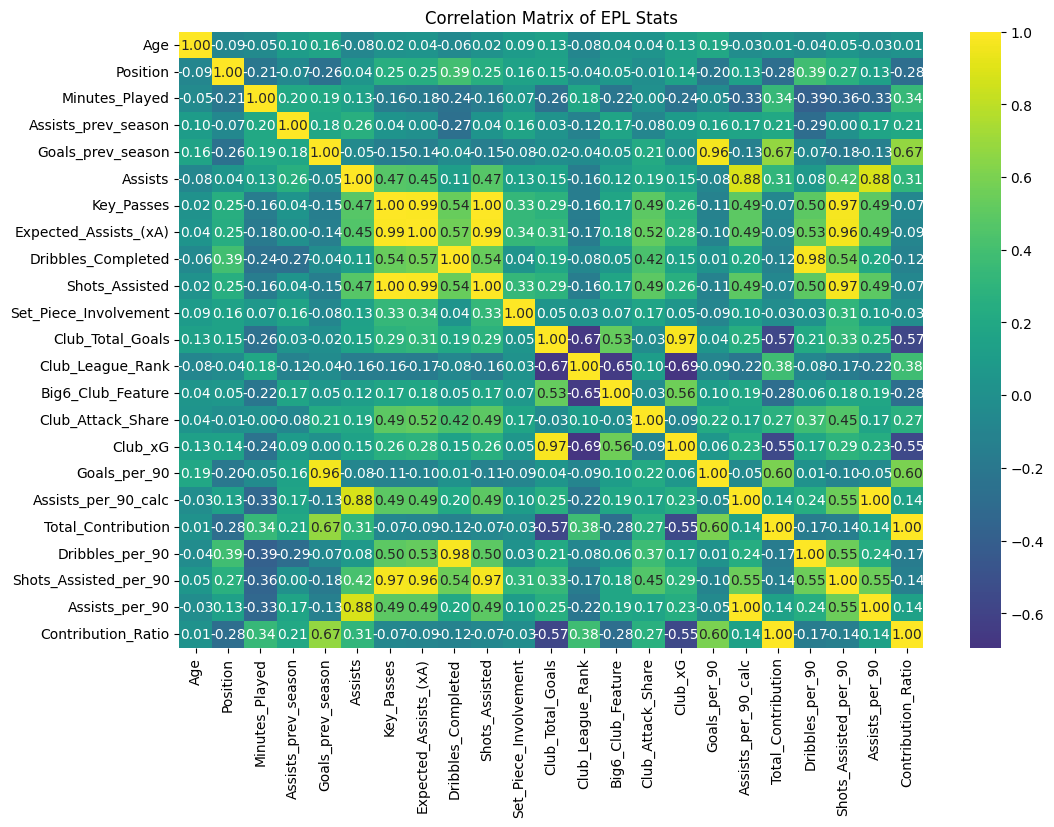

In [19]:
# Compute correlation matrix
corr = df.corr()

# Plot heatmap with values in the grid
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", center=0)
plt.title("Correlation Matrix of EPL Stats")
plt.show()

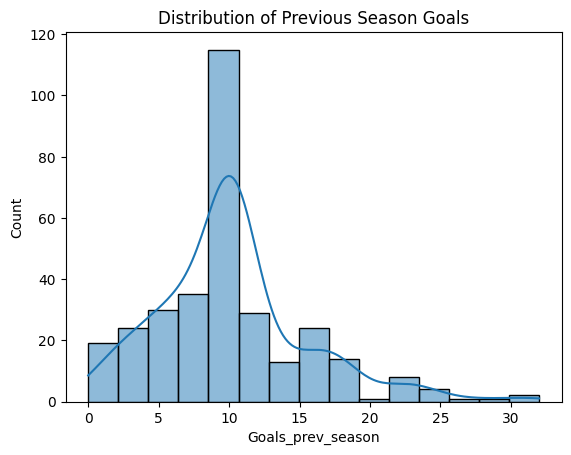

In [21]:
# Data visualization
sns.histplot(df["Goals_prev_season"], bins=15, kde=True)
plt.title("Distribution of Previous Season Goals")
plt.show()

In [23]:
# Feature matrix and target variable
X = df.drop(columns=["Goals_prev_season"])
y = df["Goals_prev_season"]

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Mean Squared Error: 1.384
Root Mean Squared Error: 1.177
R² Score: 0.959


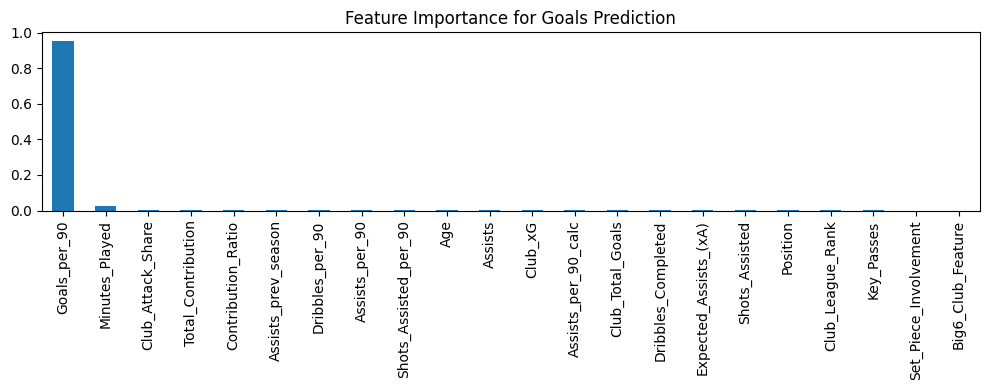

In [27]:
# Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediction & Evaluation
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# Feature importance plot
plt.figure(figsize=(10,4))
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance for Goals Prediction")
plt.tight_layout()
plt.show()